In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

### Required Package Installation

In [2]:
import os
import sys
import scgpt as scg

import warnings
import scanpy as sc
import scib
import numpy as np

import matplotlib.pyplot as plt
import anndata
import torch
torch.manual_seed(1606) 
import numpy as np
np.random.seed(1606)    
import random
random.seed(1606)     
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from pathlib import Path


import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams

plt.style.context('default')
warnings.simplefilter("ignore", ResourceWarning)

### Path Configuration

In [3]:
model_dir = Path("ZeroShotModelFiles/")
sample_data_path = "DataSet/TCGA_mrna.h5ad"

### Loading and Preprocessing Input Data

In [4]:
TCGA = sc.read_h5ad(sample_data_path)

gene_col = "gene"
cell_type_key = "cohort"
batch_key = "cohort"
N_HVG = 2000

In [5]:
celltype_id_labels = TCGA.obs[cell_type_key].astype("category").cat.codes.values
TCGA = TCGA[celltype_id_labels >= 0]

In [6]:
org_adata = TCGA.copy()

In [ ]:
# highly variable genes
sc.pp.highly_variable_genes(TCGA,  flavor='seurat_v3')
TCGA = TCGA[:, TCGA.var['highly_variable']]

### Pre-trained Embedding

In [7]:
embed_adata = scg.tasks.embed_data(
    TCGA,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
    device = torch.device("cuda")
)

scGPT - INFO - match 60694/60694 genes in vocabulary of size 60697.


In [8]:
embeddings = embed_adata.obsm["X_scGPT"].copy()
TCGA.obsm["X_scGPT"] = embeddings

In [9]:
def embedding_plots(
    data,
    classes,
    random_state=1606,
    figsize=(9, 5),
    point_size=10,
    alpha=0.7,
    legend_title="Cohort"
):
    le = LabelEncoder()
    y_encoded = le.fit_transform(classes)
    palette = sns.color_palette("tab20", 20) + sns.color_palette("Set3", 13)

    tsne_model = TSNE(
        n_components=2,      
        perplexity=30,       
        random_state=random_state,   
        metric="euclidean"
    )
    tsne_embeddings = tsne_model.fit_transform(data)

    umap_model = umap.UMAP(
        random_state=random_state,
        metric="euclidean",
        n_neighbors=10,
        min_dist=0.5
    )
    umap_embeddings = umap_model.fit_transform(data)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=y_encoded, 
                    cmap="tab20", s=point_size, alpha=alpha)
    axes[0].set_title("UMAP", fontsize=11)

    axes[1].scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], c=y_encoded, 
                    cmap="tab20", s=point_size, alpha=alpha)
    axes[1].set_title("t-SNE", fontsize=11)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_box_aspect(1) 
    # ----------------------------------------------

    labels = [str(x).split("-", 1)[-1] for x in le.classes_]
    handles = [plt.Line2D([], [], marker="o", color=palette[i % len(palette)], 
               linestyle="", markersize=6, label=label) for i, label in enumerate(labels)]

    fig.legend(handles=handles, title=legend_title, loc="lower center", 
               bbox_to_anchor=(0.5, -0.1), ncol=min(len(labels), 6), 
               prop={"size": 7}, frameon=False)

    plt.subplots_adjust(wspace=0.15)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

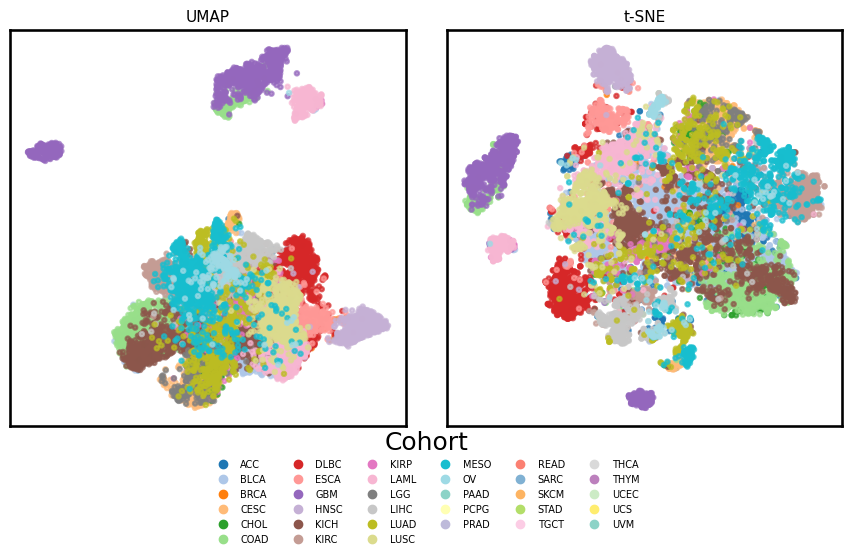

In [10]:
embedding_plots(TCGA.obsm["X_scGPT"],TCGA.obs.cohort)

### Multiclass Classification

In [11]:
X_train, X_test, y_train, y_test = train_test_split(TCGA.obsm["X_scGPT"], TCGA.obs.cohort,
                                                    test_size = 0.2, random_state = 1234,
                                                    shuffle = True, stratify = TCGA.obs.cohort)

kfold_cv = StratifiedKFold(n_splits = 4, shuffle = True, random_state = 1234)

param_grid = {"n_estimators": [100, 200, 300]}

grid_search = GridSearchCV(RandomForestClassifier(random_state = 1234), param_grid = param_grid, cv = kfold_cv)

grid_search.fit(X_train, y_train)

y_train_hat = grid_search.predict(X_train)
print(accuracy_score(y_train, y_train_hat))

y_test_hat = grid_search.predict(X_test)
print(accuracy_score(y_test, y_test_hat))

1.0
0.7207207207207207


In [12]:
np.savetxt("scGPT_pretained_embeddings.csv", 
           TCGA.obsm["X_scGPT"], delimiter=",")